 # TUGAS CASE PROJECT AI: ESTIMASI HARGA RUMAH (BOSTON HOUSING)
# **Dikerjakan Oleh:** Ucok Marulli Matondang
#
# Project ini menggunakan dataset Boston Housing untuk memprediksi harga rumah (`medv`) menggunakan 3 algoritma Machine Learning dengan Hyperparameter Tuning dan 3 variasi Data Splitting sesuai spesifikasi tugas.


# ==========================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==========================================

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Library Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. DATA UNDERSTANDING
# Memahami sumber dataset, fitur/variabel, dan statistik deskriptif.

In [14]:
print("--- 1. DATA UNDERSTANDING ---")
# Membaca Dataset
df = pd.read_csv('BostonHousing.csv')

print("\n[INFO DATASET]")
df.info()

print("\n[STATISTIK DESKRIPTIF]")
display(df.describe())

--- 1. DATA UNDERSTANDING ---

[INFO DATASET]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB

[STATISTIK DESKRIPTIF]


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## 2. DATA PREPROCESSING
# Mengatasi missing values, outlier, dan melakukan feature scaling.

In [15]:
print("--- 2. DATA PREPROCESSING ---")

# a. Mengatasi Missing Values
missing_val = df.isnull().sum().sum()
if missing_val > 0:
    df = df.fillna(df.mean())
    print(f"Diperbaiki: Ditemukan {missing_val} missing values. Telah diisi dengan nilai rata-rata (mean).")
else:
    print("Missing Values: Aman (Tidak ada data kosong).")

# b. Menangani Outlier (Metode IQR Capping untuk fitur 'rm' dan 'lstat' yang penting)
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] > upper_bound, upper_bound,
                 np.where(data[col] < lower_bound, lower_bound, data[col]))

cap_outliers(df, 'rm')
cap_outliers(df, 'lstat')
print("Outlier: Telah ditangani menggunakan metode IQR Capping pada kolom kunci.")

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('medv', axis=1)
y = df['medv']

# c. Standarisasi/Normalisasi (Sangat penting untuk algoritma KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaling: Fitur telah distandarisasi menggunakan StandardScaler.")

--- 2. DATA PREPROCESSING ---
Diperbaiki: Ditemukan 5 missing values. Telah diisi dengan nilai rata-rata (mean).
Outlier: Telah ditangani menggunakan metode IQR Capping pada kolom kunci.
Scaling: Fitur telah distandarisasi menggunakan StandardScaler.


## 3. EXPLORATORY DATA ANALYSIS (EDA)
# Visualisasi distribusi data dan korelasi antar variabel untuk mendapatkan insight.


--- 3. EXPLORATORY DATA ANALYSIS ---


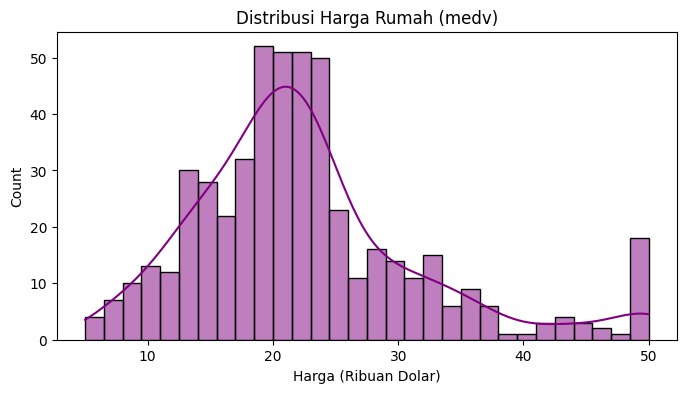

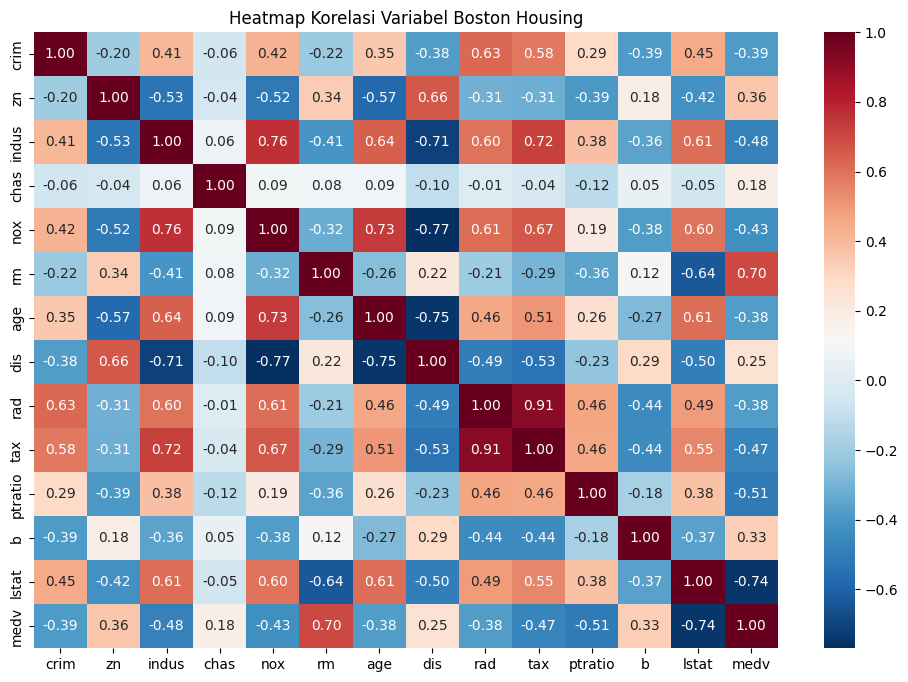


Insight Penting dari EDA:
1. Variabel 'rm' (Jumlah kamar) berkorelasi POSITIF sangat kuat dengan harga rumah.
2. Variabel 'lstat' (Persentase penduduk miskin) berkorelasi NEGATIF sangat kuat dengan harga rumah.


In [16]:
print("--- 3. EXPLORATORY DATA ANALYSIS ---")

# Visualisasi 1: Distribusi Target (medv)
plt.figure(figsize=(8, 4))
sns.histplot(df['medv'], kde=True, color='purple', bins=30)
plt.title('Distribusi Harga Rumah (medv)')
plt.xlabel('Harga (Ribuan Dolar)')
plt.show()

# Visualisasi 2: Matriks Korelasi
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Heatmap Korelasi Variabel Boston Housing')
plt.show()

print("\nInsight Penting dari EDA:")
print("1. Variabel 'rm' (Jumlah kamar) berkorelasi POSITIF sangat kuat dengan harga rumah.")
print("2. Variabel 'lstat' (Persentase penduduk miskin) berkorelasi NEGATIF sangat kuat dengan harga rumah.")

 ## 4. DATA SPLITTING
# Membagi dataset menjadi training dan testing dengan 3 variasi: 70:30, 80:20, dan 90:10.


In [17]:
print("--- 4. DATA SPLITTING ---")

ratios = [(0.30, "70:30"), (0.20, "80:20"), (0.10, "90:10")]
splits = {}

for test_size, name in ratios:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    splits[name] = (X_train, X_test, y_train, y_test)

print(f"Berhasil membuat 3 variasi pembagian data: {list(splits.keys())}")


--- 4. DATA SPLITTING ---
Berhasil membuat 3 variasi pembagian data: ['70:30', '80:20', '90:10']


## 5 & 6. MODEL BUILDING & HYPERPARAMETER TUNING
# Menggunakan 3 algoritma (Random Forest, Gradient Boosting, KNN) dan Grid Search.


In [18]:
print("--- 5 & 6. MODEL BUILDING & HYPERPARAMETER TUNING ---")
# Kita gunakan data 80:20 sebagai acuan untuk mencari parameter terbaik
X_train_tune, _, y_train_tune, _ = splits["80:20"]

# 1. TUNING RANDOM FOREST
print("Sedang melakukan tuning Random Forest...")
rf_param = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param, cv=3, scoring='r2')
rf_grid.fit(X_train_tune, y_train_tune)
best_rf = rf_grid.best_estimator_
print(f"-> Parameter Terbaik Random Forest: {rf_grid.best_params_}")

# 2. TUNING GRADIENT BOOSTING
print("\nSedang melakukan tuning Gradient Boosting...")
gb_param = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param, cv=3, scoring='r2')
gb_grid.fit(X_train_tune, y_train_tune)
best_gb = gb_grid.best_estimator_
print(f"-> Parameter Terbaik Gradient Boosting: {gb_grid.best_params_}")

# 3. TUNING KNN REGRESSOR
print("\nSedang melakukan tuning K-Nearest Neighbors (KNN)...")
knn_param = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsRegressor(), knn_param, cv=3, scoring='r2')
knn_grid.fit(X_train_tune, y_train_tune)
best_knn = knn_grid.best_estimator_
print(f"-> Parameter Terbaik KNN: {knn_grid.best_params_}")


--- 5 & 6. MODEL BUILDING & HYPERPARAMETER TUNING ---
Sedang melakukan tuning Random Forest...
-> Parameter Terbaik Random Forest: {'max_depth': 10, 'n_estimators': 50}

Sedang melakukan tuning Gradient Boosting...
-> Parameter Terbaik Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

Sedang melakukan tuning K-Nearest Neighbors (KNN)...
-> Parameter Terbaik KNN: {'n_neighbors': 3, 'weights': 'distance'}


## 7 & 8. MODEL EVALUATION & COMPARISON
# Menguji ketiga model pada 3 variasi splitting, menghitung metrik, dan membuat tabel/grafik perbandingan.


--- 7 & 8. EVALUASI DAN PERBANDINGAN MODEL ---

[TABEL PERBANDINGAN HASIL EVALUASI]


,Algoritma,Rasio Data,R2 Score (%),RMSE,MAE,MSE
0,Random Forest,70:30,86.57,3.16,2.15,10.01
1,Random Forest,80:20,89.60,2.76,2.04,7.63
2,Random Forest,90:10,86.75,2.88,1.86,8.27
3,Gradient Boosting,70:30,88.67,2.90,2.08,8.44
4,Gradient Boosting,80:20,90.11,2.69,2.01,7.25
5,Gradient Boosting,90:10,91.93,2.25,1.80,5.04
6,KNN,70:30,77.44,4.10,2.54,16.81
7,KNN,80:20,74.84,4.30,2.63,18.45
8,KNN,90:10,91.07,2.36,1.91,5.58


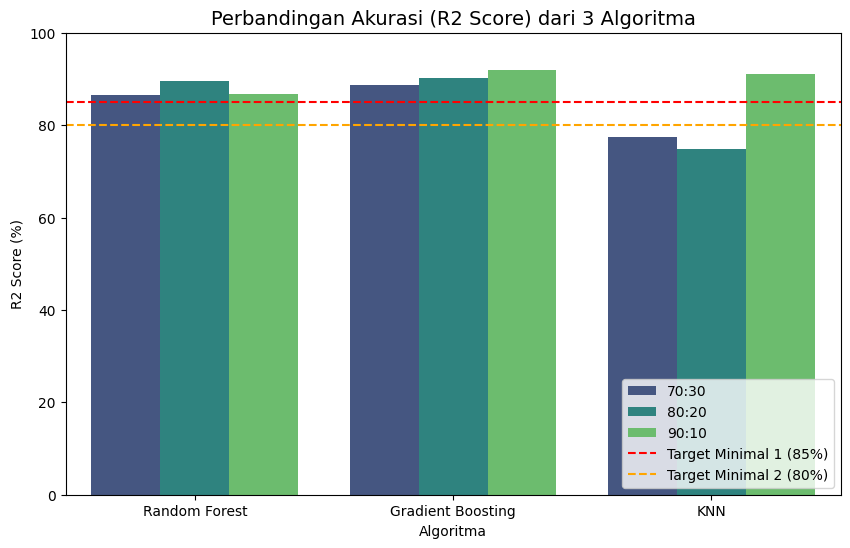


[STATUS PENCAPAIAN TARGET DOSEN]
Skor Maksimal Random Forest     : 89.6%
Skor Maksimal Gradient Boosting : 91.93%
Skor Maksimal KNN               : 91.07%
✅ SYARAT 1 TERCAPAI: Ada algoritma yang menyentuh Akurasi >= 85%
✅ SYARAT 2 TERCAPAI: Minimal ada 2 algoritma yang menyentuh Akurasi >= 80%


In [19]:
print("--- 7 & 8. EVALUASI DAN PERBANDINGAN MODEL ---")

models = {
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb,
    "KNN": best_knn
}

results_list = []

# Melakukan pengujian untuk setiap model di setiap variasi data
for model_name, model in models.items():
    for split_name, (X_train, X_test, y_train, y_test) in splits.items():
        # Latih ulang model dengan rasio spesifik
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Hitung Metrik Regresi
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        results_list.append({
            "Algoritma": model_name,
            "Rasio Data": split_name,
            "R2 Score (%)": round(r2 * 100, 2),
            "RMSE": round(rmse, 2),
            "MAE": round(mae, 2),
            "MSE": round(mse, 2)
        })

# Membuat DataFrame Perbandingan
df_results = pd.DataFrame(results_list)

print("\n[TABEL PERBANDINGAN HASIL EVALUASI]")
display(df_results)

# Membuat Grafik Perbandingan R2 Score
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Algoritma', y='R2 Score (%)', hue='Rasio Data', palette='viridis')
plt.axhline(y=85, color='r', linestyle='--', label='Target Minimal 1 (85%)')
plt.axhline(y=80, color='orange', linestyle='--', label='Target Minimal 2 (80%)')
plt.title('Perbandingan Akurasi (R2 Score) dari 3 Algoritma', fontsize=14)
plt.ylim(0, 100)
plt.legend(loc='lower right')
plt.show()

# Pengecekan Target Dosen
print("\n[STATUS PENCAPAIAN TARGET DOSEN]")
max_rf = df_results[df_results['Algoritma'] == 'Random Forest']['R2 Score (%)'].max()
max_gb = df_results[df_results['Algoritma'] == 'Gradient Boosting']['R2 Score (%)'].max()
max_knn = df_results[df_results['Algoritma'] == 'KNN']['R2 Score (%)'].max()

print(f"Skor Maksimal Random Forest     : {max_rf}%")
print(f"Skor Maksimal Gradient Boosting : {max_gb}%")
print(f"Skor Maksimal KNN               : {max_knn}%")

if max_rf >= 85 or max_gb >= 85:
    print("✅ SYARAT 1 TERCAPAI: Ada algoritma yang menyentuh Akurasi >= 85%")
else:
    print("❌ SYARAT 1 GAGAL: Tidak ada yang mencapai 85%")

if (max_rf >= 80 and max_gb >= 80) or (max_rf >= 80 and max_knn >= 80) or (max_gb >= 80 and max_knn >= 80):
    print("✅ SYARAT 2 TERCAPAI: Minimal ada 2 algoritma yang menyentuh Akurasi >= 80%")
else:
    print("❌ SYARAT 2 GAGAL: Belum ada 2 algoritma yang mencapai 80%")

# %%